# ROC 和 AUC 的完整计算过程

## 🧪 原始数据（10 个样本）

我们根据 Score 从高到低排序，方便我们逐步设定阈值：

| 序号 | Class | Score |
|------|-------|-------|
| 1    | P     | 0.93  |
| 2    | P     | 0.85  |
| 3    | N     | 0.80  |
| 4    | N     | 0.70  |
| 5    | P     | 0.55  |
| 6    | N     | 0.50  |
| 7    | N     | 0.40  |
| 8    | P     | 0.30  |
| 9    | N     | 0.20  |
| 10   | N     | 0.10  |

将 P 转换成 1，N 转换成 0，得到：

```python
y_true   = [1, 1, 0, 0, 1, 0, 0, 1, 0, 0]
y_score  = [0.93, 0.85, 0.80, 0.70, 0.55, 0.50, 0.40, 0.30, 0.20, 0.10]
```

## 📏 步骤一：逐步调整阈值

我们从高到低设置阈值，每次将 Score >= **阈值** 的样本预测为正类（P）。

我们有 4 个真实正类（P），6 个真实负类（N）：

- 正类总数 P = 4
- 负类总数 N = 6

我们依次从每个分数作为阈值，共同组成 ROC 曲线的点。

## ✅ 计算过程

| 阈值  | TP | FP | TN | FN | TPR = TP/P | FPR = FP/N |
|-------|----|----|----|----|------------|------------|
| ∞     | 0  | 0  | 6  | 4  | 0.00       | 0.00       |
| 0.93  | 1  | 0  | 6  | 3  | 0.25       | 0.00       |
| 0.85  | 2  | 0  | 6  | 2  | 0.50       | 0.00       |
| 0.80  | 2  | 1  | 5  | 2  | 0.50       | 0.17       |
| 0.70  | 2  | 2  | 4  | 2  | 0.50       | 0.33       |
| 0.55  | 3  | 2  | 4  | 1  | 0.75       | 0.33       |
| 0.50  | 3  | 3  | 3  | 1  | 0.75       | 0.50       |
| 0.40  | 3  | 4  | 2  | 1  | 0.75       | 0.67       |
| 0.30  | 4  | 4  | 2  | 0  | 1.00       | 0.67       |
| 0.20  | 4  | 5  | 1  | 0  | 1.00       | 0.83       |
| 0.10  | 4  | 6  | 0  | 0  | 1.00       | 1.00       |

## 📈 步骤二：绘制 ROC 曲线数据点

从上表中提取 (FPR, TPR) 坐标点：
- (0.00, 0.00)
- (0.00, 0.25)
- (0.00, 0.50)
- (0.17, 0.50)
- (0.33, 0.50)
- (0.33, 0.75)
- (0.50, 0.75)
- (0.67, 0.75)
- (0.67, 1.00)
- (0.83, 1.00)
- (1.00, 1.00)

## 📏 步骤三：计算 AUC

使用梯形法则求解面积：
- AUC 是 ROC 曲线下方的面积，我们使用 `sklearn.metrics.auc(fpr, tpr)` 自动计算得：
  ```python
  AUC = 0.75
  ```

你也可以手动用梯形法：
```python
AUC ≈ Σ 0.5 * (FPR[i+1] - FPR[i]) * (TPR[i+1] + TPR[i])
```

## ✅ 小结
- ROC 曲线 = 多个阈值下的 (FPR, TPR) 点连成的曲线
- AUC = 这条曲线下方的面积
- 本例中：AUC = 0.75，说明分类器对正负样本有一定的区分能力

# AUC 含义解释

"AUC 是 ROC 曲线下面积，其物理意义是，正样本的预测结果大于负样本的预测结果的概率，本质是 AUC 反映的是分类器对样本的排序能力。"

---

🔍 **拆解理解**

✅ **1. AUC 是 ROC 曲线下面积**

- AUC 是曲线与横轴之间的面积，数值范围在 0~1 之间
- 面积越大，说明分类器越容易把正负样本区分开

---

✅ **2. “正样本的预测结果大于负样本的预测结果的概率”**

这是一种非常直观的概率解释：

假设你从所有预测结果中：
- 随机抽一个正样本的预测分数
- 随机抽一个负样本的预测分数

那么：
- AUC = 这个正样本分数 > 负样本分数 的概率

也就是说，AUC 就是分类器有多大概率能把一个正样本排在一个负样本前面。

---

✅ **3. 本质是分类器的“排序能力”**

传统分类模型会输出一个“概率”或者“分数”表示是正例的可能性。

比如：

| 样本 | 真实标签 | 模型打分 |
|------|----------|----------|
| A    | 正例     | 0.95     |
| B    | 负例     | 0.20     |
| C    | 正例     | 0.88     |
| D    | 负例     | 0.40     |

我们关心的不是它打多少分，而是：
- 能不能把正例 A、C 排在负例 B、D 前面？

也就是说，只要排序对了，不管阈值设在哪，最终我们都能找到一个合适点来分类。

所以 AUC 本质上考察的是“分类器的打分排序能力”，而不是单一某个分类阈值下的表现。

---

🔑 **总结一句话**：

AUC 不是看你“分数有多高”，而是看你能不能正确地把正例排在负例前面。AUC 越高，排序能力越强，模型越稳。

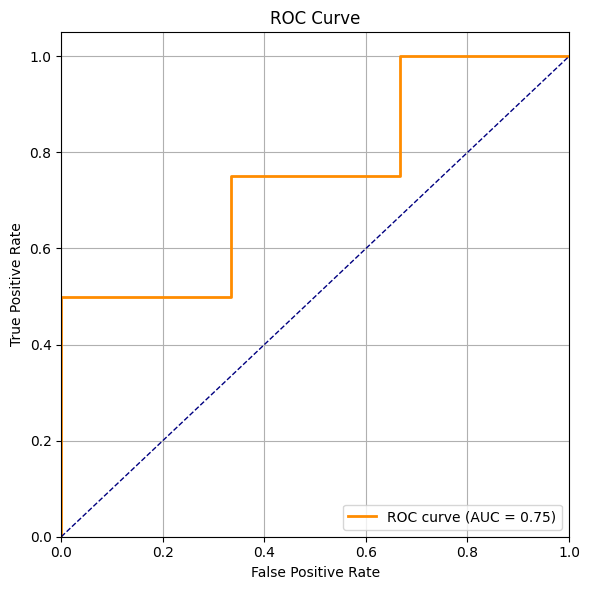

In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 标签（P=1，N=0）和对应的预测得分
y_true = [1, 1, 0, 0, 1, 0, 0, 1, 0, 0]  # Class: P=1, N=0
y_scores = [0.93, 0.85, 0.80, 0.70, 0.55, 0.50, 0.40, 0.30, 0.20, 0.10]

# 计算 ROC 曲线和 AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()